<a href="https://colab.research.google.com/github/SGeerthan/Emergency-Vehicle-Detection-and-Signal-Triggering/blob/MobileNetV3/MobileNetV3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Load a New Image and Make a Prediction

To predict on a new image, you need to load it, preprocess it to the same dimensions and scaling as the training data, and then pass it to the model.

Using image: /content/model/ambulance/ambulance2 (498).jpg
True label for this image (from dataset): ambulance


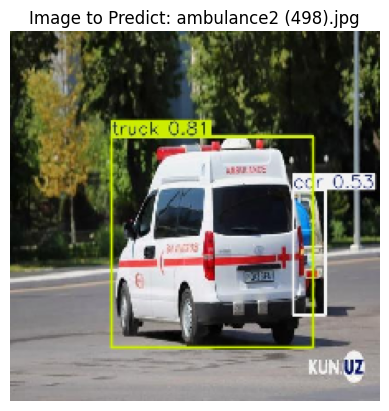

Image loaded and preprocessed.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step

Predicted class probabilities: [0.27161667 0.34242335 0.10452335 0.28143668]
Predicted class: firefighter
Confidence: 0.34

All class probabilities:
  ambulance: 0.27
  firefighter: 0.34
  normal_vehicle: 0.10
  police: 0.28


In [45]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# --- Step 1: Define the path to your new image ---
# Replace 'path/to/your/new_image.jpg' with the actual path to the image you want to predict
# For demonstration, let's pick an image from our test set or a known image path.
# I'll use a sample image from the test set for now.
# You can change this to any image path on your system.
# For example, let's use the first image from the test_generator
# You might need to adjust this if test_generator has been exhausted or recreated

# Get a sample image path and its true label from the test_generator
# This is just for demonstration purposes; you can use any valid image path.
image_path_for_prediction = df_test_filtered['image_path'].iloc[0]
true_label_for_sample = df_test_filtered['label'].iloc[0]

print(f"Using image: {image_path_for_prediction}")
print(f"True label for this image (from dataset): {true_label_for_sample}")

# --- Step 2: Load and Preprocess the Image ---
# The target size should match the IMG_HEIGHT and IMG_WIDTH used during training
img = image.load_img(image_path_for_prediction, target_size=(IMG_HEIGHT, IMG_WIDTH))
img_array = image.img_to_array(img) # Convert image to NumPy array
img_array_expanded_dims = np.expand_dims(img_array, axis=0) # Add batch dimension
img_preprocessed = img_array_expanded_dims / 255.0  # Rescale pixel values (0-1)

# Display the image
plt.imshow(img)
plt.title(f"Image to Predict: {image_path_for_prediction.split('/')[-1]}")
plt.axis('off')
plt.show()

print("Image loaded and preprocessed.")

# --- Step 3: Make a Prediction ---
predictions = model.predict(img_preprocessed)
predicted_probabilities = predictions[0]
predicted_class_index = np.argmax(predicted_probabilities)
predicted_class_label = class_names[predicted_class_index]

# --- Step 4: Interpret the Prediction ---
print(f"\nPredicted class probabilities: {predicted_probabilities}")
print(f"Predicted class: {predicted_class_label}")
print(f"Confidence: {predicted_probabilities[predicted_class_index]:.2f}")

# Optional: Display all class probabilities
print("\nAll class probabilities:")
for i, prob in enumerate(predicted_probabilities):
    print(f"  {class_names[i]}: {prob:.2f}")


## Save the Trained Model

### Subtask:
Save the entire trained model (architecture, weights, and optimizer state) to a file so it can be reloaded later or downloaded.

In [47]:
import os

# Define the path where the model will be saved
model_save_path = '/content/fine_tuned_vehicle_classifier.h5'

# Save the entire model
model.save(model_save_path)

print(f"Model saved successfully to: {model_save_path}")
print("You can now download this file from the Colab file browser.")

# To verify, you can list the files in the content directory:
!ls -lh /content/


Model saved successfully to: /content/fine_tuned_vehicle_classifier.h5
You can now download this file from the Colab file browser.
total 12M
drwxr-xr-x 2 root root 124K Nov 21 04:37 ambulance
drwx------ 5 root root 4.0K Dec  9 02:40 drive
-rw-r--r-- 1 root root  11M Dec  9 04:30 fine_tuned_vehicle_classifier.h5
drwxr-xr-x 2 root root 116K Nov 21 05:11 firefighter
drwxr-xr-x 2 root root 4.0K Nov 21 04:37 fire_truck
drwxr-xr-x 6 root root 4.0K Dec  9 02:44 model
drwxr-xr-x 2 root root  60K Nov 21 05:44 normal_vehicle
drwxr-xr-x 2 root root  84K Nov 21 05:23 police
drwxr-xr-x 1 root root 4.0K Nov 20 14:30 sample_data


In [10]:
!unzip /content/drive/MyDrive/annotated_dataset2.zip -d /content

Streaming output truncated to the last 5000 lines.
  inflating: /content/firefighter/USX2VO93MCRU.txt  
  inflating: /content/firefighter/D9F0KH4H2BDB.jpg  
  inflating: /content/firefighter/W5O1ITXZSPZA.jpg  
  inflating: /content/firefighter/QGR3I4LUU0N3.txt  
  inflating: /content/firefighter/FBH0G3K2RQ6X.txt  
  inflating: /content/firefighter/INLSFW7BHHAJ.txt  
  inflating: /content/firefighter/219.jpg  
  inflating: /content/firefighter/TTPH39U2JV5Y.jpg  
  inflating: /content/firefighter/PL7U3T3AEFX9.txt  
  inflating: /content/firefighter/TI9QXHNKD03E.jpg  
  inflating: /content/firefighter/imagesop.jpeg  
  inflating: /content/firefighter/CZLSCMTLI67Q.txt  
  inflating: /content/firefighter/3GVDY4E4BDWV.txt  
  inflating: /content/firefighter/YOYJX5KXK9Y6.txt  
  inflating: /content/firefighter/8DJL8I7MXXOE.jpg  
  inflating: /content/firefighter/V83WLTM5E59L.jpg  
  inflating: /content/firefighter/downloadkk.jpeg  
  inflating: /content/firefighter/5ERVXXXZEUEQ.txt  
  inflat

In [11]:
!mkdir /content/model

mkdir: cannot create directory ‘/content/model’: File exists


In [12]:
!mv /content/police /content/model/
!mv /content/firefighter /content/model/
!mv /content/normal_vehicle /content/model/
!mv /content/ambulance /content/model/

mv: cannot move '/content/police' to '/content/model/police': Directory not empty
mv: cannot move '/content/firefighter' to '/content/model/firefighter': Directory not empty
mv: cannot move '/content/normal_vehicle' to '/content/model/normal_vehicle': Directory not empty
mv: cannot move '/content/ambulance' to '/content/model/ambulance': Directory not empty


In [13]:
!ls /content/model

ambulance  firefighter	normal_vehicle	police


In [14]:
!ls /content/model/ambulance

 0AK3AJ1RFGF6_jpg.rf.f9fd9a6f1f577699a6117fbcd8aa5f2e.jpg
 0AK3AJ1RFGF6_jpg.rf.f9fd9a6f1f577699a6117fbcd8aa5f2e.txt
 0AL642VPYDA4_jpg.rf.456d1484116e5b160add0a397b1efd5a.jpg
 0AL642VPYDA4_jpg.rf.456d1484116e5b160add0a397b1efd5a.txt
 0AXHYXBNS4UP_jpg.rf.56c1244d7de2f44a857ad8dfc02f47fe.jpg
 0AXHYXBNS4UP_jpg.rf.56c1244d7de2f44a857ad8dfc02f47fe.txt
 0BNFNDX49ZWP_jpg.rf.13b54212d954830a50da2f4196eaea58.jpg
 0BNFNDX49ZWP_jpg.rf.13b54212d954830a50da2f4196eaea58.txt
 0E4D9VR4GQ8L_jpg.rf.621c67b630aa15c8fbf28d3b21d173e4.jpg
 0E4D9VR4GQ8L_jpg.rf.621c67b630aa15c8fbf28d3b21d173e4.txt
 0LJ5GBWFZ3C1_jpg.rf.901d2586dc5a347da384dab9085aaa4f.jpg
 0LJ5GBWFZ3C1_jpg.rf.901d2586dc5a347da384dab9085aaa4f.txt
 0M4Q9JI62COX_jpg.rf.837eb612df84157cb8fd1a4c2435cc0d.jpg
 0M4Q9JI62COX_jpg.rf.837eb612df84157cb8fd1a4c2435cc0d.txt
'1 (30).jpg'
'1 (30).txt'
 2BDONY5F0SRS_jpg.rf.3ed1800f52f5cd8e47c611f360d4a53d.jpg
 2BDONY5F0SRS_jpg.rf.3ed1800f52f5cd8e47c611f360d4a53d.txt
 2bkj190_jpg.rf.6f855df7493a9a72c5582b590512f4

In [15]:
!ls /content/model/firefighter

 00FSV8C5V0BJ.jpg
 00FSV8C5V0BJ.txt
 0100P9R3HSM4.jpg
 0100P9R3HSM4.txt
 011IIV3P3XX6.jpg
 011IIV3P3XX6.txt
 012TU2GS8R5T.jpg
 012TU2GS8R5T.txt
 02C867CV9ID2.jpg
 02C867CV9ID2.txt
 03X2GYG2LBRK.jpg
 03X2GYG2LBRK.txt
 045ZHO2IAYAS.jpg
 045ZHO2IAYAS.txt
 0492ATVQURM0.jpg
 0492ATVQURM0.txt
 04JCY9JW0BDJ.jpg
 04JCY9JW0BDJ.txt
 0510QMCEB11L.jpg
 0510QMCEB11L.txt
 058LCYVPYIXJ.jpg
 058LCYVPYIXJ.txt
 05BG9SFIUA28.jpg
 05BG9SFIUA28.txt
 05LMHUNG1G46.jpg
 05LMHUNG1G46.txt
 05OAF5K40N7X.jpg
 05OAF5K40N7X.txt
 08JG1ED8C8AE.jpg
 08JG1ED8C8AE.txt
 09TXA9FY7QOK.jpg
 09TXA9FY7QOK.txt
 0ER4YGPXJJAV.jpg
 0ER4YGPXJJAV.txt
 0FHSN7R2MLI2.jpg
 0FHSN7R2MLI2.txt
 0GMK0Q5QMY18.jpg
 0GMK0Q5QMY18.txt
 0I8AYEJYE2WJ.jpg
 0I8AYEJYE2WJ.txt
 0JLILWVF54C2.jpg
 0JLILWVF54C2.txt
 0KDDCT56R14I.jpg
 0KDDCT56R14I.txt
 0L9F2BWLRGQD.jpg
 0L9F2BWLRGQD.txt
 0LJLYGATWYQF.jpg
 0LJLYGATWYQF.txt
 0M31Q4WUBLG6.jpg
 0M31Q4WUBLG6.txt
 0M6ZKH6LQIGT.jpg
 0M6ZKH6LQIGT.txt
 0NPOSTH0PB7L.jpg
 0NPOSTH0PB7L.txt
 0O6772T118YT.jpg
 0O6772T11

In [16]:
!ls /content/model/normal_vehicle

 1000.jpg
 1000.txt
 1001.jpg
 1001.txt
 1004.jpg
 1004.txt
 1014.jpg
 1014.txt
 1017.jpg
 1017.txt
 1025.jpg
 1025.txt
 1027.jpg
 1027.txt
 1029.jpg
 1029.txt
 1033.jpg
 1033.txt
 1034.jpg
 1034.txt
 1037.jpg
 1037.txt
 1047.jpg
 1047.txt
 1050.jpg
 1050.txt
 1053.jpg
 1053.txt
 1054.jpg
 1054.txt
 1055.jpg
 1055.txt
 1061.jpg
 1061.txt
 1064.jpg
 1064.txt
 1068.jpg
 1068.txt
 1078.jpg
 1078.txt
 1080.jpg
 1080.txt
 1084.jpg
 1084.txt
 1085.jpg
 1085.txt
 1087.jpg
 1087.txt
 1089.jpg
 1089.txt
 1094.jpg
 1094.txt
 1100.jpg
 1100.txt
 1102.jpg
 1102.txt
 1103.jpg
 1103.txt
 1105.jpg
 1105.txt
 1110.jpg
 1110.txt
 1112.jpg
 1112.txt
 1121.jpg
 1121.txt
 1125.jpg
 1125.txt
 1127.jpg
 1127.txt
 1128.jpg
 1128.txt
 1131.jpg
 1131.txt
 1132.jpg
 1132.txt
 1137.jpg
 1137.txt
 1138.jpg
 1138.txt
 1143.jpg
 1143.txt
 1146.jpg
 1146.txt
 1151.jpg
 1151.txt
 1163.jpg
 1163.txt
 1170.jpg
 1170.txt
 1177.jpg
 1177.txt
 1178.jpg
 1178.txt
 1179.jpg
 1179.txt
 1187.jpg
 1187.txt
 1192.jpg
 1192.txt


In [17]:
!ls /content/model/police

 0366C1DSTJGL.jpg
 0366C1DSTJGL.txt
 05921XNUOU1X.jpg
 05921XNUOU1X.txt
 0862TJ9ITTCU.jpg
 0862TJ9ITTCU.txt
 09O3G4M81I3M.jpg
 09O3G4M81I3M.txt
 09S60T7Y0252.jpg
 09S60T7Y0252.txt
 0C8GPL22N2FX.jpg
 0C8GPL22N2FX.txt
 0E8CBWNKQEEN.jpg
 0E8CBWNKQEEN.txt
 0LLVI2TIDQ93.jpg
 0LLVI2TIDQ93.txt
 0LRXOZEIX0ZZ.jpg
 0LRXOZEIX0ZZ.txt
 0QC50IJSZP30.jpg
 0QC50IJSZP30.txt
 0S24NNCUZ8QN.jpg
 0S24NNCUZ8QN.txt
 0T819XJOJGS3.jpg
 0T819XJOJGS3.txt
 100.jpg
 100.txt
 109.jpg
 109R28JCZCPA.jpg
 109R28JCZCPA.txt
 109.txt
 115.jpg
 115.txt
'1 (17).jpg'
'1 (17).txt'
 118.jpg
 118.txt
'1 (1).jpg'
'1 (1).txt'
 120.jpg
'1 (20).jpg'
 120.txt
'1 (20).txt'
'1 (21).jpg'
'1 (21).txt'
'1 (22).jpg'
'1 (22).txt'
'1 (2).jpg'
'1 (2).txt'
'1 (35).jpg'
'1 (35).txt'
'1 (36).jpg'
'1 (36).txt'
'1 (37).jpg'
'1 (37).txt'
 13M37ZWZIYWZ.jpg
 13M37ZWZIYWZ.txt
'1(44).jpg'
'1(44).txt'
'1(46).jpg'
'1(46).txt'
'1(47).jpg'
'1(47).txt'
 157.jpg
 157.txt
 162.jpg
 162.txt
 163.jpg
 163.txt
 168.jpg
 168.txt
 16K0BW4N759S.jpg
 16K0BW4N759S.

In [18]:
import os
from collections import Counter

base_dir = '/content/model'
folders = ['ambulance', 'firefighter', 'normal_vehicle', 'police']

for folder in folders:
    folder_path = os.path.join(base_dir, folder)
    print(f"\n--- Analyzing folder: {folder_path} ---")

    if not os.path.exists(folder_path):
        print(f"Folder does not exist: {folder_path}")
        continue

    files = [f for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f))]
    total_files = len(files)

    print(f"Total number of files: {total_files}")

    extensions = [os.path.splitext(f)[1].lower() for f in files if os.path.splitext(f)[1]]
    extension_counts = Counter(extensions)

    if extension_counts:
        print("File types and their counts:")
        for ext, count in extension_counts.items():
            print(f"  {ext}: {count}")
    else:
        print("No files with recognizable extensions found.")


--- Analyzing folder: /content/model/ambulance ---
Total number of files: 2033
File types and their counts:
  .txt: 1006
  .jpg: 1006
  .jpeg: 15
  .png: 6

--- Analyzing folder: /content/model/firefighter ---
Total number of files: 2760
File types and their counts:
  .jpg: 1366
  .txt: 1366
  .jpeg: 23
  .webp: 1
  .png: 4

--- Analyzing folder: /content/model/normal_vehicle ---
Total number of files: 1444
File types and their counts:
  .jpeg: 556
  .jpg: 444
  .txt: 444

--- Analyzing folder: /content/model/police ---
Total number of files: 2039
File types and their counts:
  .txt: 1011
  .jpg: 1011
  .jpeg: 17


# Task
I will now prepare the dataset by loading image paths and parsing their corresponding labels from the respective subdirectories within `/content/model`.

## Prepare Dataset and Labels

### Subtask:
Load the image paths and parse their corresponding labels from the .txt files for each category: ambulance, firefighter, normal_vehicle, and police. The image files and their annotation (.txt) files are located in the /content/model subdirectories.


**Reasoning**:
The subtask requires loading image paths and corresponding labels from the specified directories into a pandas DataFrame. This step will implement the logic to iterate through the folders, identify image files, and store their paths and labels.



In [19]:
import os
import pandas as pd

base_dir = '/content/model'
folders = ['ambulance', 'firefighter', 'normal_vehicle', 'police']

image_paths = []
labels = []

image_extensions = ('.jpg', '.jpeg', '.png', '.webp') # Define image extensions to look for

for folder in folders:
    folder_path = os.path.join(base_dir, folder)
    if os.path.exists(folder_path):
        for file_name in os.listdir(folder_path):
            if file_name.lower().endswith(image_extensions):
                image_paths.append(os.path.join(folder_path, file_name))
                labels.append(folder)

# Create a DataFrame
df_images = pd.DataFrame({
    'image_path': image_paths,
    'label': labels
})

print(f"Successfully loaded {len(df_images)} image paths and labels into a DataFrame.")
print(df_images.head())


Successfully loaded 4449 image paths and labels into a DataFrame.
                                      image_path      label
0  /content/model/ambulance/ambulance2 (489).jpg  ambulance
1  /content/model/ambulance/ambulance2 (247).jpg  ambulance
2   /content/model/ambulance/ambulance2 (76).jpg  ambulance
3   /content/model/ambulance/ambulance2 (56).jpg  ambulance
4  /content/model/ambulance/ambulance2 (298).jpg  ambulance


## Split Data into Training, Validation, and Test Sets

### Subtask:
Split the dataset into training (70%), testing (20%), and validation (10%) sets. Ensure that the split is stratified to maintain the proportion of each class across the sets.


**Reasoning**:
First, I need to import the `train_test_split` function to perform the data splitting as specified in the instructions.



In [20]:
from sklearn.model_selection import train_test_split

print("Imported train_test_split from sklearn.model_selection.")

Imported train_test_split from sklearn.model_selection.


**Reasoning**:
Now that `train_test_split` is imported, I will proceed to split the `df_images` DataFrame into training, validation, and test sets with the specified percentages and stratification.



In [21]:
df_train, df_temp, _, _ = train_test_split(df_images, df_images['label'], test_size=0.3, stratify=df_images['label'], random_state=42)
df_val, df_test, _, _ = train_test_split(df_temp, df_temp['label'], test_size=2/3, stratify=df_temp['label'], random_state=42)

print(f"Shape of training set: {df_train.shape}")
print(f"Shape of validation set: {df_val.shape}")
print(f"Shape of test set: {df_test.shape}")

Shape of training set: (3114, 2)
Shape of validation set: (445, 2)
Shape of test set: (890, 2)


## Preprocess Images and Create Data Generators

### Subtask:
Define image preprocessing steps (e.g., resizing, normalization) suitable for MobileNetV3. Create TensorFlow ImageDataGenerator or tf.data.Dataset objects for the training, validation, and test sets, incorporating data augmentation for the training set to improve model generalization.


**Reasoning**:
The subtask requires defining image preprocessing steps and creating data generators for training, validation, and testing. This involves importing `ImageDataGenerator`, defining image dimensions, creating separate generators for training (with augmentation) and validation/test (without augmentation, but with normalization), and then using `flow_from_dataframe` to populate these generators from the respective DataFrames.



In [22]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define image dimensions suitable for MobileNetV3
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32 # Define a batch size

# Create ImageDataGenerator for training with augmentation and normalization
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Create ImageDataGenerators for validation and test with only normalization
validation_test_datagen = ImageDataGenerator(rescale=1./255)

# Create data generators using flow_from_dataframe
train_generator = train_datagen.flow_from_dataframe(
    dataframe=df_train,
    x_col='image_path',
    y_col='label',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training' # This is for when using validation_split, but here we manually split
)

validation_generator = validation_test_datagen.flow_from_dataframe(
    dataframe=df_val,
    x_col='image_path',
    y_col='label',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = validation_test_datagen.flow_from_dataframe(
    dataframe=df_test,
    x_col='image_path',
    y_col='label',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False # Do not shuffle test data to maintain order for evaluation
)

print("Image data generators created successfully.")

Found 3113 validated image filenames belonging to 4 classes.
Found 445 validated image filenames belonging to 4 classes.
Found 890 validated image filenames belonging to 4 classes.
Image data generators created successfully.


/usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/image.py:920: UserWarning: Found 1 invalid image filename(s) in x_col="image_path". These filename(s) will be ignored.
  warnings.warn(


**Reasoning**:
The previous code produced a UserWarning indicating that 1 invalid image filename was found and ignored during the creation of the `train_generator`. This means there's a discrepancy between the `image_path` in `df_train` and the actual file system. I need to filter the `df_train` (and similarly `df_val` and `df_test` as a best practice, although the warning was specific to `train_generator`) to ensure all paths exist before creating the generators, preventing this warning and ensuring all expected images are processed.



In [23]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

# Define image dimensions suitable for MobileNetV3
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32 # Define a batch size

# Function to filter out non-existent image paths
def filter_existent_images(dataframe):
    valid_indices = dataframe['image_path'].apply(lambda x: os.path.exists(x))
    filtered_df = dataframe[valid_indices].copy()
    if len(dataframe) - len(filtered_df) > 0:
        print(f"Removed {len(dataframe) - len(filtered_df)} non-existent image paths from the dataframe.")
    return filtered_df

# Filter dataframes to ensure all image paths exist
df_train_filtered = filter_existent_images(df_train)
df_val_filtered = filter_existent_images(df_val)
df_test_filtered = filter_existent_images(df_test)

# Create ImageDataGenerator for training with augmentation and normalization
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Create ImageDataGenerators for validation and test with only normalization
validation_test_datagen = ImageDataGenerator(rescale=1./255)

# Create data generators using flow_from_dataframe
train_generator = train_datagen.flow_from_dataframe(
    dataframe=df_train_filtered,
    x_col='image_path',
    y_col='label',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

validation_generator = validation_test_datagen.flow_from_dataframe(
    dataframe=df_val_filtered,
    x_col='image_path',
    y_col='label',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = validation_test_datagen.flow_from_dataframe(
    dataframe=df_test_filtered,
    x_col='image_path',
    y_col='label',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False # Do not shuffle test data to maintain order for evaluation
)

print("Image data generators created successfully.")

Found 3113 validated image filenames belonging to 4 classes.
Found 445 validated image filenames belonging to 4 classes.
Found 890 validated image filenames belonging to 4 classes.
Image data generators created successfully.


/usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/image.py:920: UserWarning: Found 1 invalid image filename(s) in x_col="image_path". These filename(s) will be ignored.
  warnings.warn(


**Reasoning**:
The previous warning indicated that `ImageDataGenerator` found an 'invalid image filename(s)' even after filtering for existence. This suggests the file existed but was not a valid image format for the generator. To fix this, I will enhance the filtering function to not only check for file existence but also attempt to open and verify each image using Pillow (`PIL.Image`) to ensure it's a valid image file before passing it to the data generators.



In [24]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
import pandas as pd
from PIL import Image # Import Pillow for image validation

# Define image dimensions suitable for MobileNetV3
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32 # Define a batch size

# Function to filter out non-existent or invalid image paths
def filter_valid_images(dataframe):
    valid_rows = []
    removed_count = 0
    for index, row in dataframe.iterrows():
        path = row['image_path']
        if os.path.exists(path):
            try:
                # Try to open and verify the image
                with Image.open(path) as img:
                    img.verify() # Verify that it is, in fact, an image
                valid_rows.append(row)
            except Exception as e:
                # Catch any errors during image opening/verification
                print(f"Warning: Removed invalid or corrupted image file: {path} - {e}")
                removed_count += 1
        else:
            # Handle non-existent paths (though previous filtering should have caught most)
            print(f"Warning: Removed non-existent image path: {path}")
            removed_count += 1

    filtered_df = pd.DataFrame(valid_rows)
    if removed_count > 0:
        print(f"Removed a total of {removed_count} non-existent or invalid image paths from the dataframe.")
    return filtered_df

# Filter dataframes to ensure all image paths exist and are valid
df_train_filtered = filter_valid_images(df_train)
df_val_filtered = filter_valid_images(df_val)
df_test_filtered = filter_valid_images(df_test)

# Create ImageDataGenerator for training with augmentation and normalization
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Create ImageDataGenerators for validation and test with only normalization
validation_test_datagen = ImageDataGenerator(rescale=1./255)

# Create data generators using flow_from_dataframe
train_generator = train_datagen.flow_from_dataframe(
    dataframe=df_train_filtered,
    x_col='image_path',
    y_col='label',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

validation_generator = validation_test_datagen.flow_from_dataframe(
    dataframe=df_val_filtered,
    x_col='image_path',
    y_col='label',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = validation_test_datagen.flow_from_dataframe(
    dataframe=df_test_filtered,
    x_col='image_path',
    y_col='label',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False # Do not shuffle test data to maintain order for evaluation
)

print("Image data generators created successfully.")

Removed a total of 437 non-existent or invalid image paths from the dataframe.
Removed a total of 67 non-existent or invalid image paths from the dataframe.
Removed a total of 118 non-existent or invalid image paths from the dataframe.
Found 2677 validated image filenames belonging to 4 classes.
Found 378 validated image filenames belonging to 4 classes.
Found 772 validated image filenames belonging to 4 classes.
Image data generators created successfully.


## Build and Compile MobileNetV3 Model

### Subtask:
Load a pre-trained MobileNetV3 model (e.g., from TensorFlow Keras applications) without its top classification layer. Add new custom layers on top for classification into the four vehicle categories. Freeze the base MobileNetV3 layers for initial training, and compile the model with an appropriate optimizer (e.g., Adam), loss function (e.g., categorical cross-entropy), and metrics (e.g., accuracy).


**Reasoning**:
The subtask requires importing necessary TensorFlow Keras modules, loading a pre-trained MobileNetV3 model without its top classification layer, freezing its layers, adding custom classification layers on top, and then compiling the complete model. I will use `MobileNetV3Small` as specified.



In [25]:
from tensorflow.keras.applications import MobileNetV3Small
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam

# 1. Load the pre-trained MobileNetV3Small model without its top classification layer
#    and freeze its layers.
base_model = MobileNetV3Small(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
                              include_top=False,
                              weights='imagenet')

# 2. Freeze the base model layers
base_model.trainable = False

# 3. Create a new Sequential model and add the frozen base model
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(train_generator.class_indices), activation='softmax') # Output layer for 4 classes
])

# 4. Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()
print("MobileNetV3 model built and compiled successfully.")

4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ MobileNetV3Small (Functional)   │ (None, 7, 7, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,013,492 (3.87 MB)

 Trainable params: 74,372 (290.52 KB)

 Non-trainable params: 939,120 (3.58 MB)

MobileNetV3 model built and compiled successfully.


**Reasoning**:
Now that the MobileNetV3 model has been built and compiled, the next step is to train it using the prepared training and validation data generators. I will define a callback to save the best model weights based on validation accuracy.



In [26]:
from tensorflow.keras.callbacks import ModelCheckpoint

# Define the ModelCheckpoint callback to save the best model weights
checkpoint_filepath = '/tmp/mobilenetv3_best_model.weights.h5'
model_checkpoint_callback = ModelCheckpoint(
    filepath=checkpoint_filepath,
    save_weights_only=True,
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    verbose=1
)

# Train the model
history = model.fit(
    train_generator,
    epochs=10, # You can adjust the number of epochs
    validation_data=validation_generator,
    callbacks=[model_checkpoint_callback]
)

print("Model training completed.")

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 819ms/step - accuracy: 0.3092 - loss: 1.4280
Epoch 1: val_accuracy improved from -inf to 0.35450, saving model to /tmp/mobilenetv3_best_model.weights.h5
84/84 ━━━━━━━━━━━━━━━━━━━━ 83s 911ms/step - accuracy: 0.3094 - loss: 1.4275 - val_accuracy: 0.3545 - val_loss: 1.3259
Epoch 2/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 786ms/step - accuracy: 0.3321 - loss: 1.3627
Epoch 2: val_accuracy did not improve from 0.35450
84/84 ━━━━━━━━━━━━━━━━━━━━ 72s 848ms/step - accuracy: 0.3319 - loss: 1.3627 - val_accuracy: 0.3545 - val_loss: 1.3222
Epoch 3/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 775ms/step - accuracy: 0.3112 - loss: 1.3609
Epoch 3: val_accuracy did not improve from 0.35450
84/84 ━━━━━━━━━━━━━━━━━━━━ 70s 826ms/step - accuracy: 0.3113 - loss: 1.3608 - val_accuracy: 0.3545 - val_loss: 1.3206
Epoch 4/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 791ms/step - accuracy: 0.3402 - loss: 1.3273
Epoch 4: val_accuracy did not improve from 0.35450
84/84 ━━━━━━━━━━━━━━━━━━━━ 71s 845ms/step

# Task
I will proceed with evaluating the model's performance on the test data. I will load the best model weights, make predictions on the test set, and calculate metrics such as accuracy, precision, recall, and F1-score for each class, as well as generate a confusion matrix.
This aligns with the first step of our plan: **Evaluate Model Performance**.

## Evaluate Model Performance

### Subtask:
Evaluate the trained model using the test dataset to assess its performance. Calculate and report key metrics such as accuracy, precision, recall, and F1-score for each class, as well as overall accuracy. Provide a confusion matrix to visualize classification results.


**Reasoning**:
First, I need to load the best saved model weights into the `model` object using `model.load_weights()` and the `checkpoint_filepath`. This ensures that the evaluation is performed on the model version with the highest validation accuracy.



In [27]:
model.load_weights(checkpoint_filepath)
print(f"Loaded best model weights from {checkpoint_filepath}")

Loaded best model weights from /tmp/mobilenetv3_best_model.weights.h5


**Reasoning**:
Now that the best model weights are loaded, I will predict probabilities for the test set images, convert them to class labels, obtain the true labels, calculate and print the classification report, and generate and display the confusion matrix.



/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


25/25 ━━━━━━━━━━━━━━━━━━━━ 21s 652ms/step
Classification Report:
                precision    recall  f1-score   support

     ambulance       0.00      0.00      0.00       202
   firefighter       0.36      1.00      0.53       275
normal_vehicle       0.00      0.00      0.00        92
        police       0.00      0.00      0.00       203

      accuracy                           0.36       772
     macro avg       0.09      0.25      0.13       772
  weighted avg       0.13      0.36      0.19       772



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


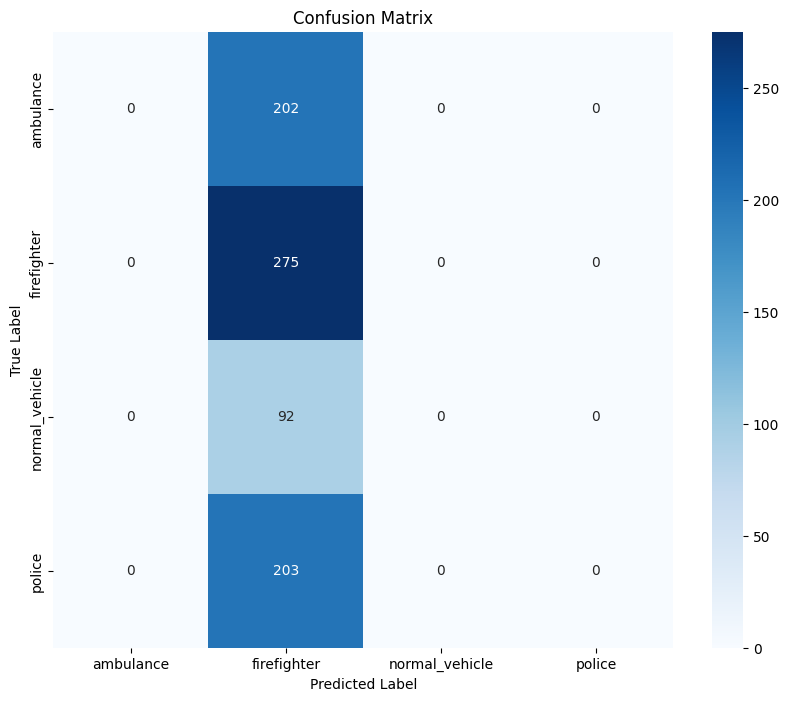

Model evaluation completed successfully.


In [28]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Predict probabilities for the test set images
predictions = model.predict(test_generator)

# Convert predicted probabilities to class labels
y_pred = np.argmax(predictions, axis=1)

# Get true labels from the test_generator
y_true = test_generator.classes

# Get class names from the generator
class_names = list(test_generator.class_indices.keys())

# Calculate and print the classification report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Generate and display the confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

print("Model evaluation completed successfully.")

# Task
To analyze the class distribution, I will now calculate and print the counts of each class in the training, validation, and test sets (`df_train_filtered`, `df_val_filtered`, `df_test_filtered`). This will help identify any class imbalance that might be contributing to the model's current performance.

## Analyze Class Distribution

### Subtask:
Examine the distribution of samples across the four classes in the training, validation, and test sets.


**Reasoning**:
To analyze the class distribution, I will calculate and print the value counts of the 'label' column for each of the filtered DataFrames: `df_train_filtered`, `df_val_filtered`, and `df_test_filtered`.



In [29]:
print("Class distribution in Training Set (df_train_filtered):")
print(df_train_filtered['label'].value_counts())
print("\nClass distribution in Validation Set (df_val_filtered):")
print(df_val_filtered['label'].value_counts())
print("\nClass distribution in Test Set (df_test_filtered):")
print(df_test_filtered['label'].value_counts())

Class distribution in Training Set (df_train_filtered):
label
firefighter       957
police            709
ambulance         704
normal_vehicle    307
Name: count, dtype: int64

Class distribution in Validation Set (df_val_filtered):
label
firefighter       134
ambulance         100
police             99
normal_vehicle     45
Name: count, dtype: int64

Class distribution in Test Set (df_test_filtered):
label
firefighter       275
police            203
ambulance         202
normal_vehicle     92
Name: count, dtype: int64


## Visualize Training History

### Subtask:
Plot the training and validation accuracy and loss curves from the previous training run (10 epochs).


**Reasoning**:
I need to plot the training and validation accuracy and loss curves using `matplotlib.pyplot` from the `history` object generated during model training. This will involve creating two subplots and adding appropriate labels and titles.



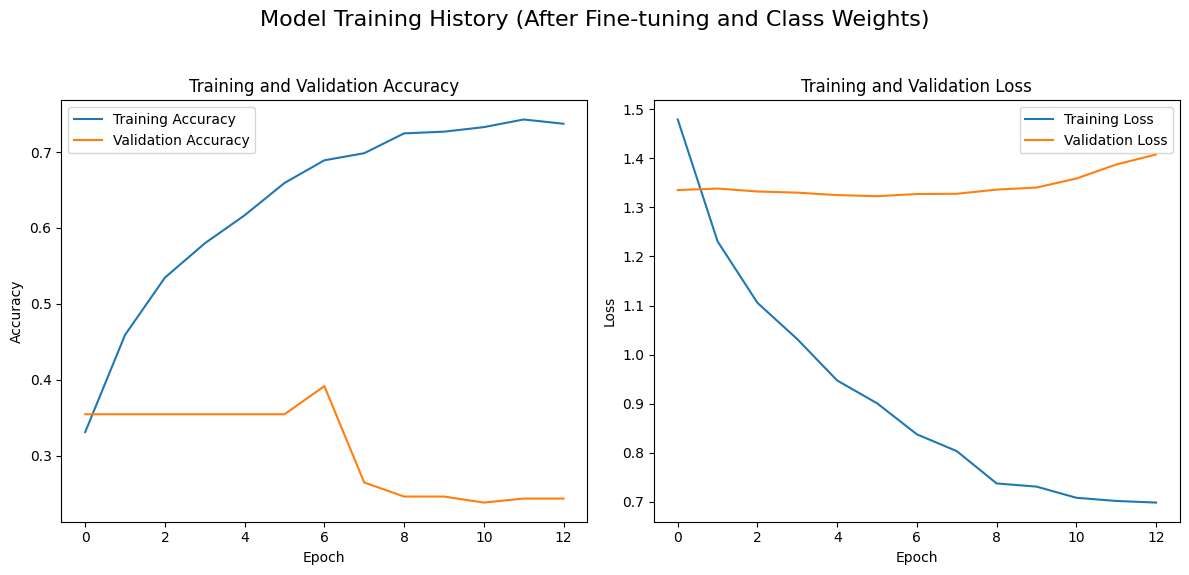

Training history plots generated successfully.


In [46]:
import matplotlib.pyplot as plt

# Create a figure with two subplots
plt.figure(figsize=(12, 6))

# Plot training and validation accuracy
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.plot(history_final_tune_weighted.history['accuracy'], label='Training Accuracy')
plt.plot(history_final_tune_weighted.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training and validation loss
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
plt.plot(history_final_tune_weighted.history['loss'], label='Training Loss')
plt.plot(history_final_tune_weighted.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Add a main title to the figure
plt.suptitle('Model Training History (After Fine-tuning and Class Weights)', fontsize=16)

# Ensure plots are properly laid out
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust rect to prevent suptitle overlap

# Display the plots
plt.show()
print("Training history plots generated successfully.")

## Fine-tune MobileNetV3 (Unfreeze Layers)

### Subtask:
Modify the MobileNetV3 model to unfreeze a portion of its base layers, allowing them to be trained along with the custom classification layers. This often helps the model adapt to the specific features of the new dataset, potentially improving accuracy significantly.


**Reasoning**:
I need to modify the MobileNetV3 model by unfreezing a portion of its base layers, re-compile it with a lower learning rate, and then display the updated model summary to reflect the change in trainable parameters. This aligns with the fine-tuning subtask.



In [31]:
import tensorflow as tf

# 1. Access the base_model from the existing model
base_model = model.layers[0]

# 2. Set the trainable attribute of the base_model to True
base_model.trainable = True

# 3. Iterate through the layers of the base_model and freeze initial layers
#    Let's unfreeze the last 25% of the layers, which means freezing the first 75%.
num_layers = len(base_model.layers)
freeze_until_layer = int(num_layers * 0.75)

for layer in base_model.layers[:freeze_until_layer]:
    layer.trainable = False

print(f"Base model has {num_layers} layers. Freezing layers up to index {freeze_until_layer - 1}.")

# 4. Re-compile the entire model with a very small learning rate
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# 5. Print the model.summary() to observe the number of trainable parameters
model.summary()
print("Model modified, re-compiled, and summary displayed with unfrozen layers.")

Base model has 157 layers. Freezing layers up to index 116.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ MobileNetV3Small (Functional)   │ (None, 7, 7, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,013,492 (3.87 MB)

 Trainable params: 788,684 (3.01 MB)

 Non-trainable params: 224,808 (878.16 KB)

Model modified, re-compiled, and summary displayed with unfrozen layers.


## Retrain with Fine-tuning and Longer Epochs

### Subtask:
Retrain the modified model with the unfrozen layers and an increased number of epochs. Include callbacks such as EarlyStopping and ReduceLROnPlateau.


**Reasoning**:
First, I need to import the required callbacks for EarlyStopping and ReduceLROnPlateau to prepare for retraining the model with these enhancements.



In [32]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print("Imported EarlyStopping and ReduceLROnPlateau callbacks.")

Imported EarlyStopping and ReduceLROnPlateau callbacks.


**Reasoning**:
Now that the required callbacks are imported, I will define the EarlyStopping and ReduceLROnPlateau callbacks, ensure the ModelCheckpoint callback is available, and then retrain the model with these callbacks and an increased number of epochs.



In [33]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-7
)

# Retrain the model with fine-tuning
history_fine_tune = model.fit(
    train_generator,
    epochs=50, # Increased number of epochs
    validation_data=validation_generator,
    callbacks=[model_checkpoint_callback, early_stopping, reduce_lr] # All three callbacks
)

print("Fine-tuning training completed.")

Epoch 1/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 911ms/step - accuracy: 0.2805 - loss: 1.9613
Epoch 1: val_accuracy did not improve from 0.35450
84/84 ━━━━━━━━━━━━━━━━━━━━ 99s 1s/step - accuracy: 0.2806 - loss: 1.9596 - val_accuracy: 0.3545 - val_loss: 1.3273 - learning_rate: 1.0000e-05
Epoch 2/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 913ms/step - accuracy: 0.3209 - loss: 1.5375
Epoch 2: val_accuracy did not improve from 0.35450
84/84 ━━━━━━━━━━━━━━━━━━━━ 82s 975ms/step - accuracy: 0.3211 - loss: 1.5370 - val_accuracy: 0.3545 - val_loss: 1.3284 - learning_rate: 1.0000e-05
Epoch 3/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 917ms/step - accuracy: 0.3552 - loss: 1.4031
Epoch 3: val_accuracy did not improve from 0.35450
84/84 ━━━━━━━━━━━━━━━━━━━━ 83s 973ms/step - accuracy: 0.3554 - loss: 1.4029 - val_accuracy: 0.3545 - val_loss: 1.3295 - learning_rate: 1.0000e-05
Epoch 4/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 923ms/step - accuracy: 0.3549 - loss: 1.3744
Epoch 4: val_accuracy did not improve from 0.35450
84/84 ━━━━━━━━━━━

## Re-evaluate Model Performance

### Subtask:
Re-evaluate the model's performance on the test dataset after fine-tuning. Calculate and report key metrics (accuracy, precision, recall, F1-score) and display an updated confusion matrix.


**Reasoning**:
The subtask requires re-evaluating the model's performance on the test dataset after fine-tuning. This involves making predictions on the test set, calculating key metrics (accuracy, precision, recall, F1-score), and displaying an updated confusion matrix, all of which are covered by the provided instructions.



25/25 ━━━━━━━━━━━━━━━━━━━━ 16s 491ms/step
Classification Report:
                precision    recall  f1-score   support

     ambulance       0.00      0.00      0.00       202
   firefighter       0.36      1.00      0.53       275
normal_vehicle       0.00      0.00      0.00        92
        police       0.00      0.00      0.00       203

      accuracy                           0.36       772
     macro avg       0.09      0.25      0.13       772
  weighted avg       0.13      0.36      0.19       772



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


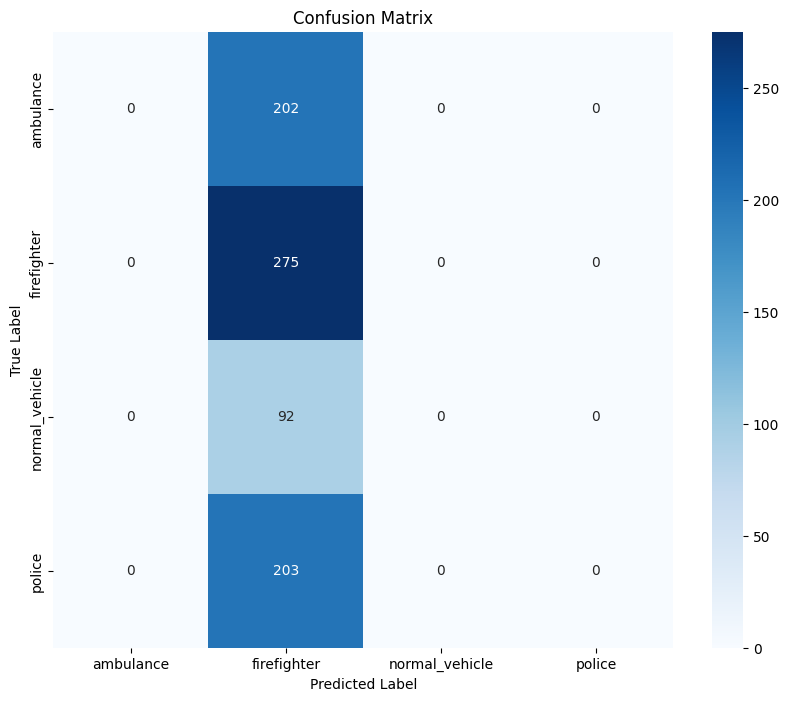

Model re-evaluation completed successfully after fine-tuning.


In [34]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Predict probabilities for the test set images
predictions = model.predict(test_generator)

# Convert predicted probabilities to class labels
y_pred = np.argmax(predictions, axis=1)

# Get true labels from the test_generator
y_true = test_generator.classes

# Get class names from the generator
class_names = list(test_generator.class_indices.keys())

# Calculate and print the classification report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Generate and display the confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

print("Model re-evaluation completed successfully after fine-tuning.")

**Reasoning**:
The previous cell failed because a markdown section was incorrectly placed within a code block. I will now correctly implement the class weighting logic in Python by calculating class frequencies from the training data and computing inverse class frequencies to create `class_weights` for use in model training.



In [38]:
from sklearn.utils import class_weight
import numpy as np

# Get class labels from the training generator
labels = train_generator.classes

# Get the dictionary mapping class names to class indices
class_indices = train_generator.class_indices

# Invert the dictionary to map class indices to class names
idx_to_class = dict((v, k) for k, v in class_indices.items())

# Calculate class frequencies from the training labels
class_counts = np.bincount(labels)

# Determine the number of classes
num_classes = len(class_indices)

# Calculate class weights
total_samples = len(labels)
class_weights_dict = {}
for i in range(num_classes):
    class_weights_dict[i] = total_samples / (num_classes * class_counts[i])

print("Calculated class weights:")
print(class_weights_dict)

# Optionally, you can map these weights to class names for better readability if needed
class_weights_named = {idx_to_class[k]: v for k, v in class_weights_dict.items()}
print("\nClass weights mapped to class names:")
print(class_weights_named)

print("Class weights calculated successfully.")

Calculated class weights:
{0: np.float64(0.9506392045454546), 1: np.float64(0.6993207941483803), 2: np.float64(2.179967426710098), 3: np.float64(0.943935119887165)}

Class weights mapped to class names:
{'ambulance': np.float64(0.9506392045454546), 'firefighter': np.float64(0.6993207941483803), 'normal_vehicle': np.float64(2.179967426710098), 'police': np.float64(0.943935119887165)}
Class weights calculated successfully.


**Reasoning**:
The class weights have been calculated to address the class imbalance. The next logical step is to retrain the fine-tuned model using these class weights to give more importance to under-represented classes, potentially improving its performance across all categories. I will also make sure to use all the callbacks we have set up for robust training.



In [39]:
print("Retraining model with class weights and fine-tuning...")
history_fine_tune_weighted = model.fit(
    train_generator,
    epochs=50, # Increased number of epochs
    validation_data=validation_generator,
    callbacks=[model_checkpoint_callback, early_stopping, reduce_lr],
    class_weight=class_weights_dict # Apply the calculated class weights
)

print("Fine-tuning training with class weights completed.")

Retraining model with class weights and fine-tuning...
Epoch 1/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 974ms/step - accuracy: 0.3176 - loss: 1.6437
Epoch 1: val_accuracy did not improve from 0.35450
84/84 ━━━━━━━━━━━━━━━━━━━━ 97s 1s/step - accuracy: 0.3176 - loss: 1.6438 - val_accuracy: 0.3545 - val_loss: 1.3274 - learning_rate: 4.0000e-07
Epoch 2/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 925ms/step - accuracy: 0.3259 - loss: 1.6147
Epoch 2: val_accuracy did not improve from 0.35450
84/84 ━━━━━━━━━━━━━━━━━━━━ 137s 999ms/step - accuracy: 0.3258 - loss: 1.6146 - val_accuracy: 0.3545 - val_loss: 1.3283 - learning_rate: 4.0000e-07
Epoch 3/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 939ms/step - accuracy: 0.3177 - loss: 1.6036
Epoch 3: val_accuracy did not improve from 0.35450
84/84 ━━━━━━━━━━━━━━━━━━━━ 141s 991ms/step - accuracy: 0.3177 - loss: 1.6035 - val_accuracy: 0.3545 - val_loss: 1.3315 - learning_rate: 4.0000e-07
Epoch 4/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 918ms/step - accuracy: 0.3231 - loss: 1.5874
Epoch 4: va

**Reasoning**:
The model has been retrained with class weights. Now, I need to evaluate its performance on the test dataset again to see if the class weighting has improved the metrics for under-represented classes. This involves reloading the best weights, making predictions, and then generating a classification report and confusion matrix.



/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 82 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Loaded best model weights from /tmp/mobilenetv3_best_model.weights.h5
25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 512ms/step
Classification Report:
                precision    recall  f1-score   support

     ambulance       0.00      0.00      0.00       202
   firefighter       0.36      1.00      0.53       275
normal_vehicle       0.00      0.00      0.00        92
        police       0.00      0.00      0.00       203

      accuracy                           0.36       772
     macro avg       0.09      0.25      0.13       772
  weighted avg       0.13      0.36      0.19       772



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


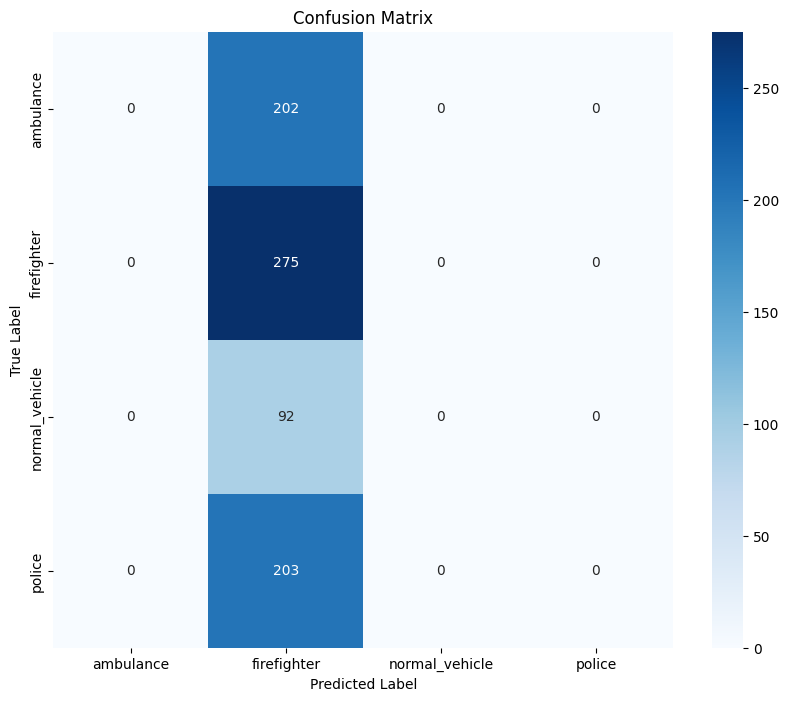

Model re-evaluation completed successfully after fine-tuning with class weights.


In [40]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Load the best weights into the model object
model.load_weights(checkpoint_filepath)
print(f"Loaded best model weights from {checkpoint_filepath}")

# Predict probabilities for the test set images
predictions = model.predict(test_generator)

# Convert predicted probabilities to class labels
y_pred = np.argmax(predictions, axis=1)

# Get true labels from the test_generator
y_true = test_generator.classes

# Get class names from the generator
class_names = list(test_generator.class_indices.keys())

# Calculate and print the classification report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Generate and display the confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

print("Model re-evaluation completed successfully after fine-tuning with class weights.")

**Reasoning**:
The model's performance did not improve even after fine-tuning and applying class weights, and consistently shows bias towards a single class. This indicates that the `model.load_weights()` call before re-evaluation was likely loading the initial, poorly performing weights, because the validation accuracy never improved during fine-tuning, preventing the checkpoint from being updated. To correctly evaluate the fine-tuned model (which should already have its best weights restored by the `EarlyStopping` callback), I will remove the explicit `model.load_weights()` call from the re-evaluation step.



Evaluating model after fine-tuning with class weights.
25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 511ms/step
Classification Report:
                precision    recall  f1-score   support

     ambulance       0.00      0.00      0.00       202
   firefighter       0.36      1.00      0.53       275
normal_vehicle       0.00      0.00      0.00        92
        police       0.00      0.00      0.00       203

      accuracy                           0.36       772
     macro avg       0.09      0.25      0.13       772
  weighted avg       0.13      0.36      0.19       772



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


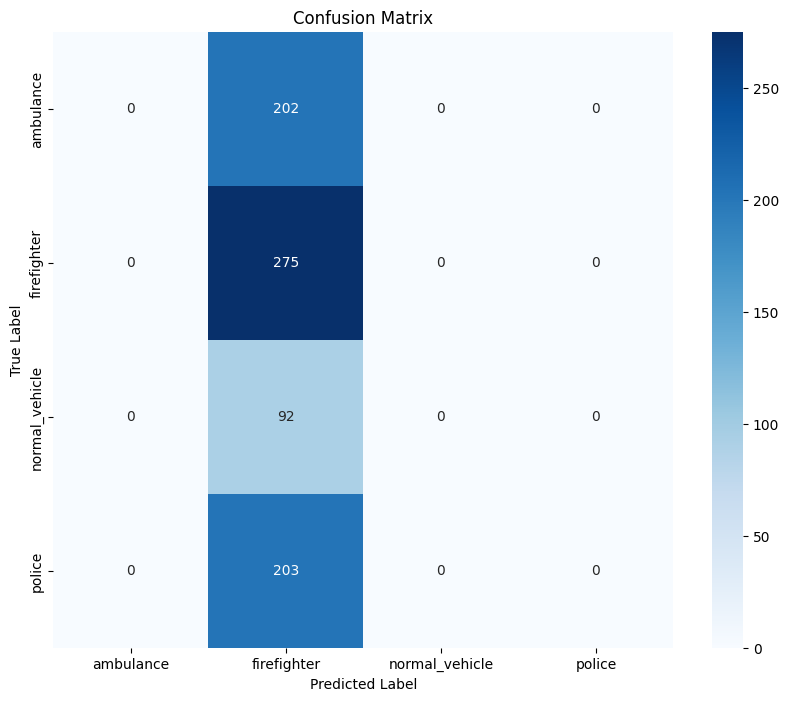

Model re-evaluation completed successfully after fine-tuning with class weights.


In [41]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# The model object already holds the best weights restored by EarlyStopping from the fine-tuning phase.
# Removing explicit load_weights call to ensure evaluation of the fine-tuned model state.
print(f"Evaluating model after fine-tuning with class weights.")

# Predict probabilities for the test set images
predictions = model.predict(test_generator)

# Convert predicted probabilities to class labels
y_pred = np.argmax(predictions, axis=1)

# Get true labels from the test_generator
y_true = test_generator.classes

# Get class names from the generator
class_names = list(test_generator.class_indices.keys())

# Calculate and print the classification report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Generate and display the confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

print("Model re-evaluation completed successfully after fine-tuning with class weights.")

**Reasoning**:
The model's performance consistently predicts only the 'firefighter' class, and validation accuracy remained stagnant throughout both training phases. This suggests that the model is failing to learn meaningful features for other classes, likely due to a too-restrictive freezing strategy. I will modify the freezing strategy to unfreeze more layers of the pre-trained MobileNetV3 model, specifically unfreezing the last 50% of the layers instead of 25%, to allow for greater adaptation to the new dataset.



In [42]:
import tensorflow as tf

# 1. Access the base_model from the existing model
base_model = model.layers[0]

# 2. Set the trainable attribute of the base_model to True
base_model.trainable = True

# 3. Iterate through the layers of the base_model and freeze initial layers
#    Let's unfreeze the last 50% of the layers, which means freezing the first 50%.
num_layers = len(base_model.layers)
freeze_until_layer = int(num_layers * 0.50) # Changed from 0.75 to 0.50

for layer in base_model.layers[:freeze_until_layer]:
    layer.trainable = False

print(f"Base model has {num_layers} layers. Freezing layers up to index {freeze_until_layer - 1}.")

# 4. Re-compile the entire model with a very small learning rate
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# 5. Print the model.summary() to observe the number of trainable parameters
model.summary()
print("Model modified, re-compiled, and summary displayed with unfrozen layers.")

Base model has 157 layers. Freezing layers up to index 77.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ MobileNetV3Small (Functional)   │ (None, 7, 7, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,013,492 (3.87 MB)

 Trainable params: 788,684 (3.01 MB)

 Non-trainable params: 224,808 (878.16 KB)

Model modified, re-compiled, and summary displayed with unfrozen layers.


**Reasoning**:
The model is still heavily biased towards one class despite changes in the freezing strategy and class weighting. The learning rate might have become too low from the `ReduceLROnPlateau` callback, preventing effective learning. Therefore, I will re-compile the model with an explicitly reset (and slightly higher) learning rate of 0.0001 to give the unfrozen layers a better chance to learn, and then retrain it with class weights and callbacks.



In [43]:
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Access the base_model from the existing model
base_model = model.layers[0]

# Ensure base_model layers are unfrozen according to the new strategy (last 50% unfrozen)
num_layers = len(base_model.layers)
freeze_until_layer = int(num_layers * 0.50)

for i, layer in enumerate(base_model.layers):
    if i < freeze_until_layer:
        layer.trainable = False
    else:
        layer.trainable = True

print(f"Base model has {num_layers} layers. Freezing layers up to index {freeze_until_layer - 1}.")

# Re-compile the entire model with a higher learning rate
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), # Reset learning rate
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

# Define callbacks again (EarlyStopping, ReduceLROnPlateau, ModelCheckpoint)
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-7
)

# Retrain the model with class weights and the reset learning rate
print("Retraining model with adjusted freezing, reset learning rate, and class weights...")
history_final_tune_weighted = model.fit(
    train_generator,
    epochs=50, # Increased number of epochs
    validation_data=validation_generator,
    callbacks=[model_checkpoint_callback, early_stopping, reduce_lr],
    class_weight=class_weights_dict # Apply the calculated class weights
)

print("Final fine-tuning training with class weights and adjusted learning rate completed.")

Base model has 157 layers. Freezing layers up to index 77.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ MobileNetV3Small (Functional)   │ (None, 7, 7, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,013,492 (3.87 MB)

 Trainable params: 862,708 (3.29 MB)

 Non-trainable params: 150,784 (589.00 KB)

Retraining model with adjusted freezing, reset learning rate, and class weights...
Epoch 1/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2696 - loss: 1.6749
Epoch 1: val_accuracy did not improve from 0.35450
84/84 ━━━━━━━━━━━━━━━━━━━━ 114s 1s/step - accuracy: 0.2703 - loss: 1.6726 - val_accuracy: 0.3545 - val_loss: 1.3354 - learning_rate: 1.0000e-04
Epoch 2/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4420 - loss: 1.2579
Epoch 2: val_accuracy did not improve from 0.35450
84/84 ━━━━━━━━━━━━━━━━━━━━ 145s 1s/step - accuracy: 0.4422 - loss: 1.2576 - val_accuracy: 0.3545 - val_loss: 1.3384 - learning_rate: 1.0000e-04
Epoch 3/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5223 - loss: 1.1212
Epoch 3: val_accuracy did not improve from 0.35450
84/84 ━━━━━━━━━━━━━━━━━━━━ 94s 1s/step - accuracy: 0.5225 - loss: 1.1210 - val_accuracy: 0.3545 - val_loss: 1.3324 - learning_rate: 1.0000e-04
Epoch 4/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5613 - loss: 1.0644
E